# Day 035: Random Forest - Theory & Implementation

**Phase 3: Tree Models & SVM**

Welcome to the advanced deep-dive into Random Forests. Today, we focus on the mathematical guarantees of variance reduction through Bagging and random feature subspaces, and implement Out-of-Bag (OOB) tracking.


## 1. Mathematical Guarantee of Variance Reduction

Why does a Random Forest perform better than a single Decision Tree? It relies on the **Variance of an Ensemble** formula.

If we have $B$ trees, each with variance $\sigma^2$ and pairwise correlation $ho$, the variance of the average prediction is:

$$ Var(F) = \rho \sigma^2 + \frac{1 - \rho}{B} \sigma^2 $$

As $B \to \infty$, the second term approaches 0. The variance is bottlenecked by $\rho \sigma^2$. To minimize the ensemble variance, we must minimize $\rho$ (the correlation between trees). Random Forest achieves this by:
1. **Bootstrap Aggregating (Bagging)**: Training on random subsets of data.
2. **Feature Subspacing**: Selecting a random subset of features at each split (usually $\sqrt{p}$), preventing dominant features from making all trees look identical.


## 2. Importing Required Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')


## 3. Dataset Preparation


In [2]:
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, random_state=42)
print(f'Data Shape: {X.shape}')


Data Shape: (1000, 20)


## 4. Out-of-Bag (OOB) Tracking

In Bagging, sampling with replacement leaves about ~36.8% of the data out of each tree's training set (Out-of-Bag samples). We can use these to validate the model *during* training without needing a separate validation set.


In [3]:
rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42, n_jobs=-1)
rf.fit(X, y)

print(f'Final OOB Score: {rf.oob_score_:.4f}')


Final OOB Score: 0.9120


### Tracking OOB Error as Trees Increase
Let's manually track the OOB error rate to see how the ensemble stabilizes as $B$ increases.


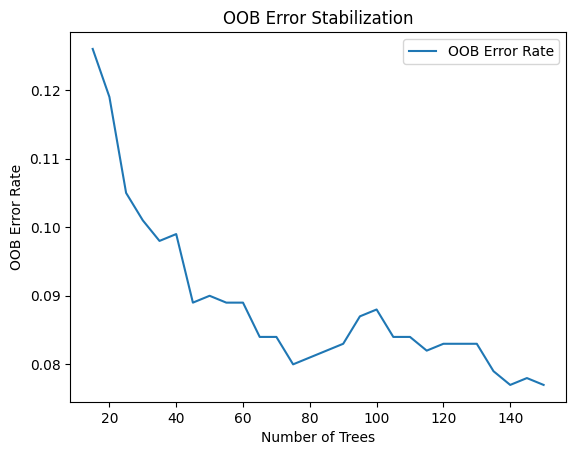

In [4]:
min_estimators = 15
max_estimators = 150
error_rate = []

for i in range(min_estimators, max_estimators + 1, 5):
    rf = RandomForestClassifier(n_estimators=i, oob_score=True, random_state=42, warm_start=True, n_jobs=-1)
    rf.fit(X, y)
    oob_error = 1 - rf.oob_score_
    error_rate.append((i, oob_error))

# Plotting
x_vals, y_vals = zip(*error_rate)
plt.plot(x_vals, y_vals, label='OOB Error Rate')
plt.xlabel('Number of Trees')
plt.ylabel('OOB Error Rate')
plt.title('OOB Error Stabilization')
plt.legend()
plt.show()


## 5. Interview Edge

**Question:** *How does Random Forest mathematically guarantee a reduction in variance compared to a single decision tree? Derive the ensemble variance formula.*

**Answer:**
A Random Forest reduces variance by averaging the predictions of $B$ identically distributed, but NOT perfectly correlated, trees. 
The variance of the average of $B$ variables with variance $\sigma^2$ and pairwise correlation $\rho$ is:
$Var(\frac{1}{B} \sum_{i=1}^B Z_i) = \rho \sigma^2 + \frac{1-\rho}{B} \sigma^2$.
Since trees are deep, they have high $\sigma^2$ (high variance, low bias). By injecting randomness (bootstrap sampling and feature subspacing), Random Forest drastically reduces $\rho$. As $B$ becomes large, the second term $\frac{1-\rho}{B}\sigma^2$ goes to 0, leaving the total variance close to $\rho \sigma^2$, which is significantly smaller than the original $\sigma^2$ of a single tree.
